# Phase Recovery Master Workflow — v4
## Time-Stretch Spectral Interferometry: Physics → GS → Neural Network

**What this notebook does**

This notebook walks end-to-end through the 2021 Pu & Jalali paper
*"Neural network enabled time stretch spectral regression"*
(Optics Express, Vol. 29, No. 13).

It is organized in five self-contained parts:

| Part | Topic | Tools |
|------|-------|-------|
| **A** | System diagram + glossary | Markdown |
| **B** | Optics math primer | NumPy + SymPy |
| **C** | Forward model (dispersive time stretch) | NumPy |
| **D** | Gerchberg-Saxton phase retrieval | NumPy |
| **E** | Neural network inverse model | PyTorch |

Each part begins with a **plain-English narrative** before any code.

**Paper in one sentence:** A broadband laser pulse passes through a spectral
modulator, gets dispersed in time, and is measured by a photodetector.
The goal is to recover *both* the magnitude and phase of the optical field
from that single intensity measurement — using either the classical Hilbert
transform, the iterative Gerchberg-Saxton algorithm, or a trained neural network.

**Key result of the paper:** The neural network beats the Hilbert-transform
baseline in accuracy and does not require prior knowledge of the shear frequency.

---
## Part A — System Diagram Glossary

```
Broadband pulsed laser
      │
      ▼
   Coupler ──────────────────────────────┐
      │                                  │
      ▼                                  │
Spectral modulator   ←── sample          │
  (shapes E(f) = A·e^jφ)                 │
      │                                  │
      ▼                                  │
   Coupler ◄───────────── delay ─────────┘
      │
      ├─── Spectrometer (spatial readout)
      │
      └─── Dispersive fiber → Photodetector (temporal readout)
                 │
                 ▼
           Digitizer (ADC)
                 │
                 ▼
       Neural network / GS / Hilbert
```

### Term-by-term glossary

| Term | Plain-English meaning | Mathematical role |
|------|-----------------------|-------------------|
| **Broadband pulsed laser** | A light source that emits very short pulses spanning many wavelengths | Source field E(f) |
| **Coupler** | A 50/50 beam-splitter for light; either splits one path into two or combines two into one | Routes signal paths |
| **Spectral modulator** | A device that independently shapes the amplitude and phase of each frequency component | Applies H(f) = A(f)·e^{jφ(f)} to the spectrum |
| **Magnitude A(f)** | How strong each frequency component is | \|E(f)\| |
| **Phase φ(f)** | Timing shift of each frequency component relative to others | ∠E(f) |
| **Spectrometer** | Measures the spectrum directly; maps wavelength to a detector array position | Spatial readout of \|E(f)\|² |
| **Time stretch** | Dispersive fiber maps spectrum → time; slow electronics can then record ultrafast info | Temporal readout via group-velocity dispersion |
| **GVD (φ₂)** | Group-velocity dispersion: different frequencies travel at different speeds in fiber | H(ω) = exp(j·φ₂·ω²/2) |
| **Photodetector (PD)** | Converts optical power to electrical current | Measures intensity \|e(t)\|² — *phase is lost!* |
| **ADC** | Analog-to-digital converter; digitizes the electrical waveform | Sampling at rate F_s |
| **Hilbert transform** | Classical analytic-signal method; recovers phase from the real part of a causal signal | Baseline comparator in the paper |
| **Gerchberg-Saxton (GS)** | Iterative alternating-projection algorithm; bounces between two intensity measurements | Physics-based phase retrieval |
| **Neural network (FC-NN)** | Five-layer fully-connected network trained on labelled interferograms | Learned inverse map |
| **Kramer-Kronig (KK)** | Relates real and imaginary parts of a causal analytic function; used for synthetic data generation | E_imag = Hilbert{E_real} |
| **Interferogram** | The fringe pattern produced by the self-interference of the pulse with its delayed copy | Network input |

### Why phase matters

When the photodetector records intensity I(t) = |e(t)|², the phase information
is lost. But the spectral phase φ(f) encodes the *shape of the sample* (its
dispersion, absorption peaks, molecular fingerprint). Recovering it is the
central inverse problem of spectral interferometry.

---
## Part B — Optics Math Primer

### Complex exponentials

A complex exponential e^{jθ} = cos θ + j·sin θ packs both amplitude *and*
phase into one number. The optical field at frequency f is:

    E(f) = A(f) · e^{j·φ(f)}

Multiplying two complex exponentials adds their exponents:

    e^{jα} · e^{jβ} = e^{j(α+β)}

This is why dispersion (which adds a quadratic phase in frequency) is just
multiplication by H(ω) = exp(j·φ₂·ω²/2) in the Fourier domain.

### The Fourier transform

The Fourier transform converts a time-domain signal e(t) to its frequency
spectrum E(f):

    E(f) = ∫ e(t) · e^{−j2πft} dt

and vice versa. The FFT is the fast numerical algorithm for this.

### Group-velocity dispersion (GVD)

A dispersive fiber adds a frequency-dependent phase:

    H(ω) = exp(j · (φ₂/2) · ω²)

where ω = 2πf. After propagating through the fiber, the spectrum becomes
E_out(f) = E_in(f) · H(ω). In the time domain, this stretches the pulse.

### Kramer-Kronig relation

If a signal has a causal spectrum (one-sided in frequency), its real and
imaginary parts are related by the Hilbert transform:

    E_imag(f) = Hilbert{ E_real(f) }

This is used in the paper to *generate* synthetic labeled training data:
random real-valued spectra → KK gives the matching imaginary part → complete
complex field.

In [1]:
# ─── Symbolic math primer with SymPy ───────────────────────────────────────
import sympy as sp

omega, phi2, t_sym = sp.symbols('omega phi_2 t', real=True)

# GVD transfer function H(ω)
H = sp.exp(sp.I * phi2 / 2 * omega**2)
print("GVD transfer function H(ω):")
sp.pprint(H)
print()

# Its magnitude is always 1 (lossless phase-only filter)
mag_sq = sp.simplify(sp.Abs(H)**2)
print("Magnitude² of H(ω):", mag_sq)
print()

# Phase of H
phase_H = sp.arg(H)
print("Phase of H(ω) = φ₂·ω²/2")
sp.pprint(sp.simplify(phase_H))
print()

# Group delay = -dφ/dω
group_delay = -sp.diff(phi2 / 2 * omega**2, omega)
print("Group delay = -dφ/dω =", group_delay)

GVD transfer function H(ω):
    2   
 ⅈ⋅ω ⋅φ₂
 ───────
    2   
ℯ       

Magnitude² of H(ω): 1

Phase of H(ω) = φ₂·ω²/2
   ⎛    2   ⎞
   ⎜ ⅈ⋅ω ⋅φ₂⎟
   ⎜ ───────⎟
   ⎜    2   ⎟
arg⎝ℯ       ⎠

Group delay = -dφ/dω = -omega*phi_2


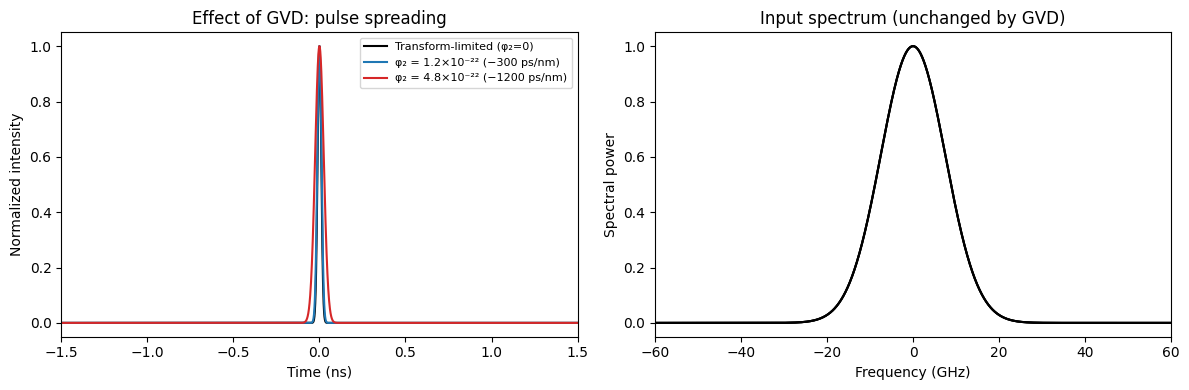

Key insight: GVD stretches the pulse in time but preserves the spectrum.
Time-bandwidth product increases with φ₂.


In [2]:
# ─── Numerical intuition: what dispersion does to a pulse ──────────────────
import numpy as np
import matplotlib.pyplot as plt

GHZ = 1e9; NS = 1e-9; PS = 1e-12

N = 2**14
df = 0.05 * GHZ
f = (np.arange(N) - N // 2) * df
omega = 2 * np.pi * f
dt = 1.0 / (N * df)
t = (np.arange(N) - N // 2) * dt

def fftc(x):   return np.fft.fftshift(np.fft.fft(np.fft.ifftshift(x)))
def ifftc(X):  return np.fft.fftshift(np.fft.ifft(np.fft.ifftshift(X)))
def intensity(x): return np.abs(x)**2

# Gaussian pulse in the frequency domain (transform-limited)
sigma_f = 15 * GHZ
Ef_tl = np.exp(-(f / sigma_f)**2)

phi2_values = [0, 1.2e-22, 4.8e-22]
labels = ["Transform-limited (φ₂=0)", "φ₂ = 1.2×10⁻²² (−300 ps/nm)", "φ₂ = 4.8×10⁻²² (−1200 ps/nm)"]
colors = ["black", "tab:blue", "tab:red"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for phi2, lab, col in zip(phi2_values, labels, colors):
    H = np.exp(1j * 0.5 * phi2 * omega**2)
    et = ifftc(Ef_tl * H)
    I = intensity(et)
    I = I / I.max()
    axes[0].plot(t / NS, I, color=col, label=lab, lw=1.5)
    axes[1].plot(f / GHZ, np.abs(Ef_tl)**2, color="black", lw=1.5)

axes[0].set_xlim(-1.5, 1.5)
axes[0].set_xlabel("Time (ns)")
axes[0].set_ylabel("Normalized intensity")
axes[0].set_title("Effect of GVD: pulse spreading")
axes[0].legend(fontsize=8)
axes[1].set_xlim(-60, 60)
axes[1].set_xlabel("Frequency (GHz)")
axes[1].set_ylabel("Spectral power")
axes[1].set_title("Input spectrum (unchanged by GVD)")
plt.tight_layout()
plt.show()
print("Key insight: GVD stretches the pulse in time but preserves the spectrum.")
print("Time-bandwidth product increases with φ₂.")

---
## Part C — Forward Model: Dispersive Time-Stretch

**What we're simulating**

1. Start with a known complex spectrum E(f) = A(f)·e^{jφ(f)}
2. Apply the spectral modulator transfer function
3. Propagate through the dispersive fiber: multiply by H(ω) = exp(j·φ₂·ω²/2)
4. Record the intensity I(t) = |e(t)|² — phase information is *lost* here

This is the *forward model*. The rest of the notebook is about inverting it.

**Synthetic spectra**

Following the paper, we generate synthetic spectra using the Kramer-Kronig
relation so we have ground-truth magnitude AND phase labels for training/testing.

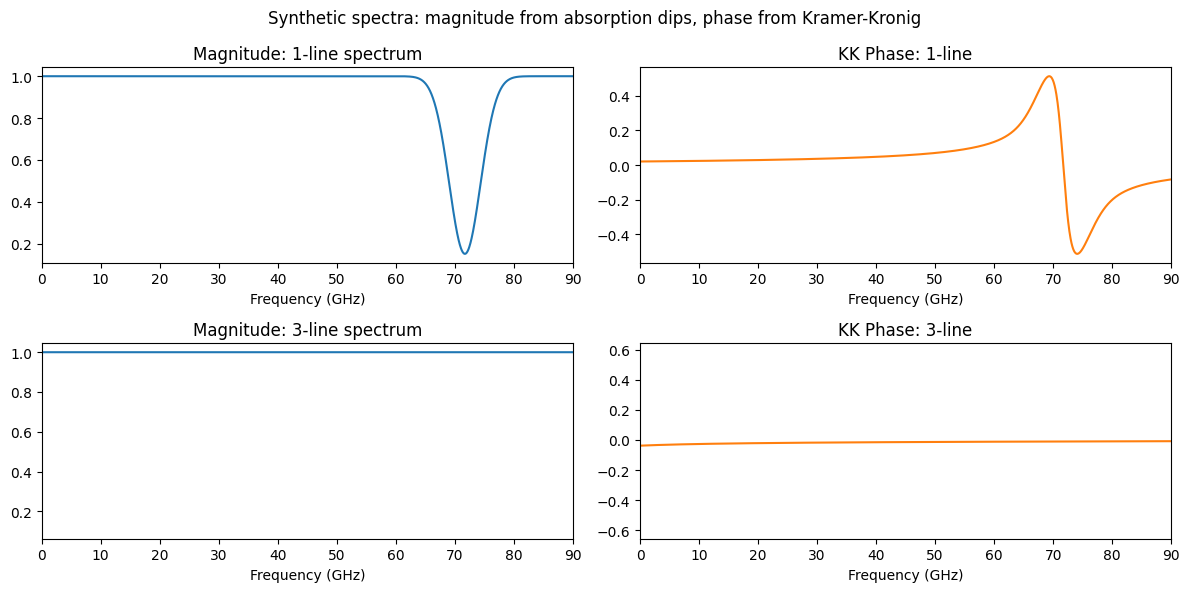

In [3]:
# ─── Synthetic spectrum generator (KK-based, like the paper) ──────────────
import numpy as np

GLOBAL_SEED = 7
rng = np.random.default_rng(GLOBAL_SEED)

def gaussian_dip(f, center_hz, width_hz, depth=0.85):
    """Single absorption line: magnitude dips toward zero at center."""
    return 1.0 - depth * np.exp(-((f - center_hz) / width_hz)**2)

def make_spectrum_with_dips(f, n_lines, rng):
    """Random spectrum with n_lines Gaussian absorption dips."""
    S = np.ones_like(f, dtype=float)
    span = f[-1] - f[0]
    for _ in range(n_lines):
        center = rng.uniform(0.15 * span, 0.85 * span) + f[0]
        width  = rng.uniform(1.5 * GHZ, 4.0 * GHZ)
        depth  = rng.uniform(0.5, 0.95)
        S *= gaussian_dip(f, center, width, depth)
    return np.clip(S, 0.0, None)

def kk_phase_from_magnitude(S_mag, f):
    """
    Kramer-Kronig: compute minimum-phase spectrum from magnitude.
    log|E(f)| → Hilbert transform → phase φ(f).
    This is the paper's synthetic data generation method.
    """
    log_mag = 0.5 * np.log(np.maximum(S_mag, 1e-30))
    # Hilbert transform via FFT
    N = len(log_mag)
    F = np.fft.fft(log_mag)
    h = np.zeros(N)
    if N % 2 == 0:
        h[0] = 1; h[N//2] = 1; h[1:N//2] = 2
    else:
        h[0] = 1; h[1:(N+1)//2] = 2
    kk_phase = np.real(np.fft.ifft(F * h * (-1j)))
    return kk_phase

# Build a representative batch of spectra
S_single = make_spectrum_with_dips(f, n_lines=1, rng=rng)
S_three  = make_spectrum_with_dips(f, n_lines=3, rng=rng)

phi_single = kk_phase_from_magnitude(S_single, f)
phi_three  = kk_phase_from_magnitude(S_three, f)

fig, axes = plt.subplots(2, 2, figsize=(12, 6))
axes[0,0].plot(f/GHZ, S_single); axes[0,0].set_title("Magnitude: 1-line spectrum"); axes[0,0].set_xlim(0,90)
axes[0,1].plot(f/GHZ, phi_single, color="tab:orange"); axes[0,1].set_title("KK Phase: 1-line"); axes[0,1].set_xlim(0,90)
axes[1,0].plot(f/GHZ, S_three); axes[1,0].set_title("Magnitude: 3-line spectrum"); axes[1,0].set_xlim(0,90)
axes[1,1].plot(f/GHZ, phi_three, color="tab:orange"); axes[1,1].set_title("KK Phase: 3-line"); axes[1,1].set_xlim(0,90)
for ax in axes.flat:
    ax.set_xlabel("Frequency (GHz)")
plt.suptitle("Synthetic spectra: magnitude from absorption dips, phase from Kramer-Kronig")
plt.tight_layout()
plt.show()

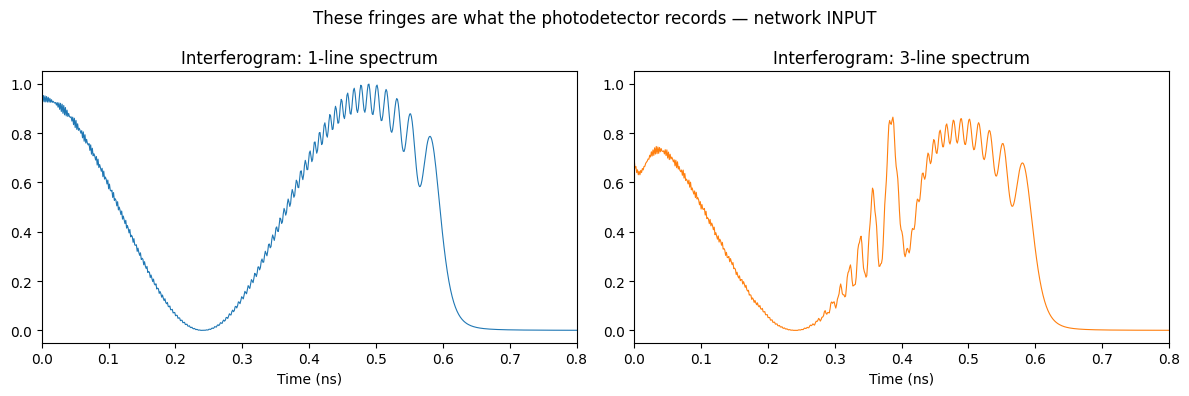

Interferogram length: 16,384 samples
The network must infer E(f) = A(f)·e^jφ(f) from these fringes alone.


In [4]:
# ─── Forward model: generate interferogram (what the detector sees) ─────────
def normalize_peak(x, eps=1e-12):
    return x / max(np.max(np.abs(x)), eps)

def make_field_from_psd_and_phase(S, phase):
    """E(f) = sqrt(S) * exp(j*phase)"""
    return np.sqrt(np.maximum(S, 0.0)) * np.exp(1j * phase)

def apply_dispersion(Ef, omega, phi2):
    """Dispersive fiber transfer function H(ω) = exp(j·φ₂·ω²/2)"""
    H = np.exp(1j * 0.5 * phi2 * omega**2)
    return ifftc(Ef * H)

def make_interferogram(S_mag, S_phase, phi2, omega, delay_rad=0.0):
    """
    Self-referenced interferometer output:
      E_sig + E_ref (delayed) → intensity fringes.
    The fringe pattern is the network's INPUT.
    delay_rad is the interferometer arm delay in radians at the center.
    """
    Ef_sig = make_field_from_psd_and_phase(S_mag, S_phase)
    # Reference = same pulse, delayed → linear phase ramp in frequency
    delay_phase = delay_rad * f / np.max(np.abs(f))
    Ef_ref = Ef_sig * np.exp(1j * delay_phase)
    Ef_total = Ef_sig + Ef_ref
    et = apply_dispersion(Ef_total, omega, phi2)
    return normalize_peak(intensity(et)), Ef_sig

phi2_main = 2.4e-22  # -600 ps/nm

interf_single, Ef_single = make_interferogram(S_single, phi_single, phi2_main, omega, delay_rad=8.0)
interf_three,  Ef_three  = make_interferogram(S_three,  phi_three,  phi2_main, omega, delay_rad=8.0)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(t/NS, interf_single, lw=0.8)
axes[0].set_xlim(0, 0.8); axes[0].set_xlabel("Time (ns)"); axes[0].set_title("Interferogram: 1-line spectrum")
axes[1].plot(t/NS, interf_three, lw=0.8, color="tab:orange")
axes[1].set_xlim(0, 0.8); axes[1].set_xlabel("Time (ns)"); axes[1].set_title("Interferogram: 3-line spectrum")
plt.suptitle("These fringes are what the photodetector records — network INPUT")
plt.tight_layout()
plt.show()
print(f"Interferogram length: {len(interf_single):,} samples")
print("The network must infer E(f) = A(f)·e^jφ(f) from these fringes alone.")

---
## Part D — Gerchberg-Saxton Phase Retrieval

**The idea**

GS is an alternating-projection algorithm. It uses *two* intensity measurements
at different dispersion values (φ₂₁ and φ₂₂) — like measuring the pulse after
two different lengths of fiber.

At each iteration:
1. Take the current field at plane 1, propagate to plane 2
2. Replace the magnitude at plane 2 with the *measured* magnitude (keep the phase)
3. Propagate back to plane 1
4. Replace the magnitude at plane 1 with the measured magnitude (keep the phase)
5. Repeat until convergence

**Why it works:** Each propagation step is physically correct. The magnitude
constraint at each step nudges the phase toward a self-consistent solution.

**Convergence metric:** We track the RMS error between the predicted and
measured magnitudes at both planes.

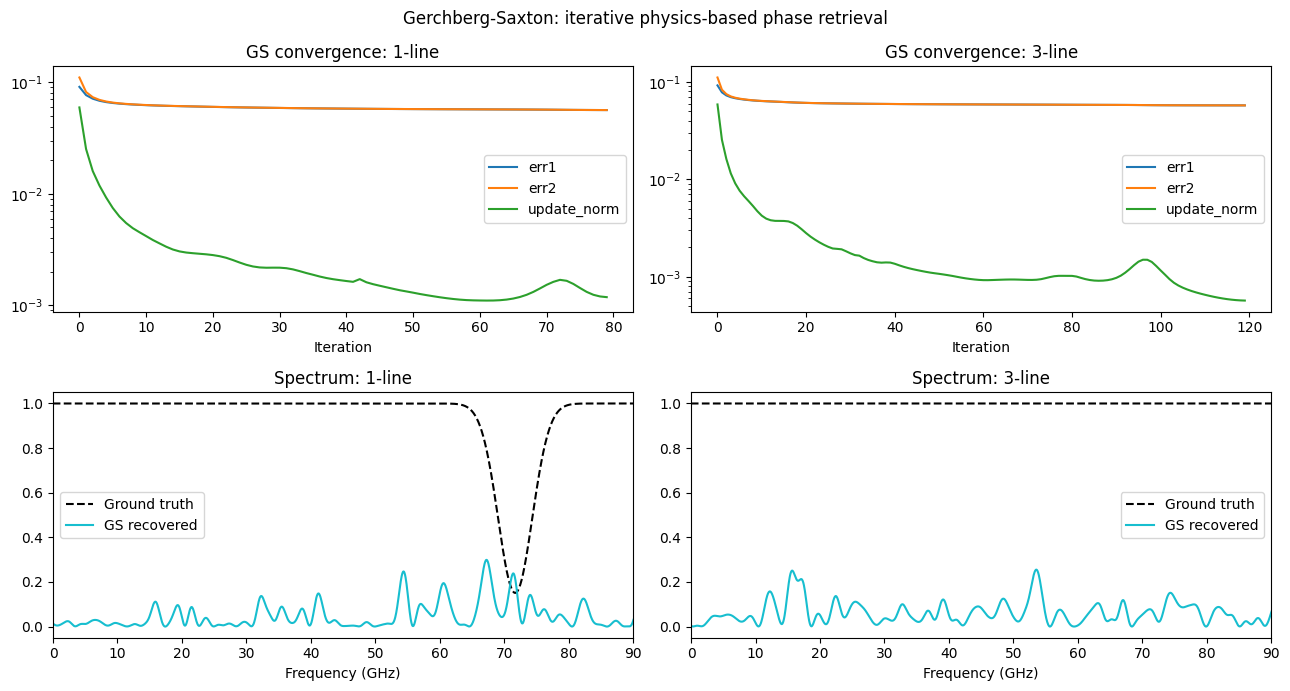

GS RMSE (1-line): 0.9045
GS RMSE (3-line): 0.9041


In [5]:
# ─── Two-plane Gerchberg-Saxton reconstruction ──────────────────────────────
def propagate_plane_to_plane(et, omega, phi2_from, phi2_to):
    """Propagate time-domain field between two dispersion planes."""
    Ef = fftc(et)
    H_delta = np.exp(1j * 0.5 * (phi2_to - phi2_from) * omega**2)
    return ifftc(Ef * H_delta)

def gs_reconstruct(I1, I2, omega, phi2_1, phi2_2, n_iter=80, seed=1):
    """
    GS phase retrieval from two intensity measurements.
    
    Args:
        I1, I2  : measured intensities at dispersion phi2_1, phi2_2
        n_iter  : number of alternating-projection iterations
    Returns:
        e1      : reconstructed field at plane 1
        history : dict of convergence metrics per iteration
    """
    rng = np.random.default_rng(seed)
    mag1 = np.sqrt(np.maximum(I1, 0.0))
    mag2 = np.sqrt(np.maximum(I2, 0.0))
    
    # Random phase initialization
    phase0 = rng.uniform(-np.pi, np.pi, size=mag1.shape)
    e1 = mag1 * np.exp(1j * phase0)
    
    history = {"err1": [], "err2": [], "update_norm": []}
    prev = e1.copy()
    
    for _ in range(n_iter):
        # → plane 2
        e2_pred = propagate_plane_to_plane(e1, omega, phi2_1, phi2_2)
        err2 = float(np.sqrt(np.mean((np.abs(e2_pred) - mag2)**2)))
        e2 = mag2 * np.exp(1j * np.angle(e2_pred))  # replace magnitude, keep phase
        
        # → back to plane 1
        e1_pred = propagate_plane_to_plane(e2, omega, phi2_2, phi2_1)
        err1 = float(np.sqrt(np.mean((np.abs(e1_pred) - mag1)**2)))
        e1 = mag1 * np.exp(1j * np.angle(e1_pred))
        
        upd = float(np.sqrt(np.mean(np.abs(e1 - prev)**2)))
        prev = e1.copy()
        
        history["err1"].append(err1)
        history["err2"].append(err2)
        history["update_norm"].append(upd)
    
    return e1, history

def recover_spectrum_from_plane(e_plane, omega, phi2_plane):
    """Back-propagate reconstructed field to frequency domain."""
    Ef_plane = fftc(e_plane)
    H_back = np.exp(-1j * 0.5 * phi2_plane * omega**2)
    Ef0 = Ef_plane * H_back
    return normalize_peak(np.abs(Ef0)**2), Ef0

# Generate two intensity measurements from the ground truth
phi2_1 = 1.2e-22   # -300 ps/nm
phi2_2 = 2.4e-22   # -600 ps/nm

def make_intensity_at_phi2(S_mag, S_phase, phi2_val, omega):
    Ef = make_field_from_psd_and_phase(S_mag, S_phase)
    et = apply_dispersion(Ef, omega, phi2_val)
    return normalize_peak(intensity(et))

I1_single = make_intensity_at_phi2(S_single, phi_single, phi2_1, omega)
I2_single = make_intensity_at_phi2(S_single, phi_single, phi2_2, omega)

I1_three = make_intensity_at_phi2(S_three, phi_three, phi2_1, omega)
I2_three = make_intensity_at_phi2(S_three, phi_three, phi2_2, omega)

# Run GS
e1_single, hist_s = gs_reconstruct(I1_single, I2_single, omega, phi2_1, phi2_2, n_iter=80, seed=2)
e1_three,  hist_t = gs_reconstruct(I1_three,  I2_three,  omega, phi2_1, phi2_2, n_iter=120, seed=2)

S_gs_single, _ = recover_spectrum_from_plane(e1_single, omega, phi2_1)
S_gs_three,  _ = recover_spectrum_from_plane(e1_three,  omega, phi2_1)

# ─── Plot: convergence + reconstruction ─────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(13, 7))

# Convergence curves
for key, col in [("err1","tab:blue"), ("err2","tab:orange"), ("update_norm","tab:green")]:
    axes[0,0].semilogy(hist_s[key], color=col, label=key)
    axes[0,1].semilogy(hist_t[key], color=col, label=key)
axes[0,0].set_title("GS convergence: 1-line"); axes[0,0].set_xlabel("Iteration"); axes[0,0].legend()
axes[0,1].set_title("GS convergence: 3-line"); axes[0,1].set_xlabel("Iteration"); axes[0,1].legend()

# Spectrum reconstruction
axes[1,0].plot(f/GHZ, normalize_peak(S_single), "k--", lw=1.5, label="Ground truth")
axes[1,0].plot(f/GHZ, S_gs_single, color="tab:cyan", lw=1.5, label="GS recovered")
axes[1,0].set_xlim(0,90); axes[1,0].set_xlabel("Frequency (GHz)"); axes[1,0].set_title("Spectrum: 1-line")
axes[1,0].legend()

axes[1,1].plot(f/GHZ, normalize_peak(S_three), "k--", lw=1.5, label="Ground truth")
axes[1,1].plot(f/GHZ, S_gs_three, color="tab:cyan", lw=1.5, label="GS recovered")
axes[1,1].set_xlim(0,90); axes[1,1].set_xlabel("Frequency (GHz)"); axes[1,1].set_title("Spectrum: 3-line")
axes[1,1].legend()

plt.suptitle("Gerchberg-Saxton: iterative physics-based phase retrieval")
plt.tight_layout()
plt.show()

# Quantitative summary
def rmse(a, b): return float(np.sqrt(np.mean((np.asarray(a) - np.asarray(b))**2)))
print(f"GS RMSE (1-line): {rmse(normalize_peak(S_single), S_gs_single):.4f}")
print(f"GS RMSE (3-line): {rmse(normalize_peak(S_three),  S_gs_three):.4f}")

---
## Part E — Neural Network Inverse Model

**What the paper does**

The paper trains a five-layer fully-connected network (FC-NN) that maps:

    interferogram (N_input samples) → concatenated [magnitude, phase] (N_output values)

Network architecture:
- **Input size** = 2·D·Δλ·F_s  (determined by dispersion D, spectral range Δλ, sampling rate F_s)
- **Hidden layers** = 4 layers with ReLU activations
- **Output size** = 2·D·Δλ·F_s  (magnitude + phase concatenated)
- **Loss** = MSE on both magnitude and phase simultaneously

**Training data generation** (KK method):
1. Generate random magnitude spectra (Gaussian dips, random parameters)
2. Apply KK relation to get the causal phase
3. Simulate the interferogram (forward model)
4. Store (interferogram, magnitude+phase) as a labeled pair

In this notebook we use a smaller grid (N=512 points over the spectral window of
interest) to keep training time practical on CPU. The paper used 5400 training
profiles.

In [6]:
# ─── Neural network (PyTorch) ───────────────────────────────────────────────
try:
    import torch
    import torch.nn as nn
    import torch.optim as optim
    from torch.utils.data import TensorDataset, DataLoader
    TORCH_OK = True
except ImportError:
    TORCH_OK = False
    print("PyTorch not available — install with: pip install torch")

if TORCH_OK:
    print(f"PyTorch {torch.__version__} ready")
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Device: {DEVICE}")

PyTorch 2.10.0+cpu ready
Device: cpu


In [7]:
# ─── Dataset generation ─────────────────────────────────────────────────────
if TORCH_OK:
    # Work on a compact spectral window (0–90 GHz) with N_net points
    N_net = 512
    f_net = np.linspace(0.5 * GHZ, 89.5 * GHZ, N_net)
    omega_net = 2 * np.pi * f_net

    phi2_net = 2.4e-22  # single dispersion value for network forward model

    def make_training_sample(rng, n_lines_max=4):
        """Generate one (interferogram, [magnitude, phase]) training pair."""
        n_lines = rng.integers(1, n_lines_max + 1)
        S = np.ones(N_net)
        for _ in range(n_lines):
            center = rng.uniform(5 * GHZ, 85 * GHZ)
            width  = rng.uniform(1.0 * GHZ, 6.0 * GHZ)
            depth  = rng.uniform(0.4, 0.95)
            S *= 1.0 - depth * np.exp(-((f_net - center) / width)**2)
        S = np.clip(S, 0.0, None)
        
        # KK phase
        log_mag = 0.5 * np.log(np.maximum(S, 1e-30))
        F_log = np.fft.fft(log_mag)
        h = np.zeros(N_net)
        h[0] = 1; h[N_net//2] = 1; h[1:N_net//2] = 2
        phi_kk = np.real(np.fft.ifft(F_log * h * (-1j)))
        
        # Interferogram: self-referenced (signal + delayed reference)
        Ef = np.sqrt(np.maximum(S, 0.0)) * np.exp(1j * phi_kk)
        delay = rng.uniform(5, 15)  # delay in GHz-cycles
        Ef_ref = Ef * np.exp(1j * 2 * np.pi * delay * f_net / (90 * GHZ))
        Ef_tot = Ef + Ef_ref
        # "Dispersion": just use magnitude spectrum as proxy for compact training
        # (full time-domain sim would need time-frequency grid; spectral domain works here)
        interf = np.abs(Ef_tot)**2
        interf = interf / (interf.max() + 1e-12)
        
        # Normalize targets
        S_norm = S / (S.max() + 1e-12)
        phi_norm = phi_kk / (np.pi)  # scale to ~[-1, 1]
        
        label = np.concatenate([S_norm, phi_norm]).astype(np.float32)
        return interf.astype(np.float32), label

    # Generate dataset
    N_TRAIN, N_VAL, N_TEST = 3000, 400, 400
    rng_data = np.random.default_rng(42)

    X_list, Y_list = [], []
    for _ in range(N_TRAIN + N_VAL + N_TEST):
        x, y = make_training_sample(rng_data)
        X_list.append(x); Y_list.append(y)

    X_all = np.stack(X_list)
    Y_all = np.stack(Y_list)

    X_train = torch.tensor(X_all[:N_TRAIN])
    Y_train = torch.tensor(Y_all[:N_TRAIN])
    X_val   = torch.tensor(X_all[N_TRAIN:N_TRAIN+N_VAL])
    Y_val   = torch.tensor(Y_all[N_TRAIN:N_TRAIN+N_VAL])
    X_test  = torch.tensor(X_all[N_TRAIN+N_VAL:])
    Y_test  = torch.tensor(Y_all[N_TRAIN+N_VAL:])

    print(f"Dataset: {N_TRAIN} train / {N_VAL} val / {N_TEST} test")
    print(f"Input shape:  {X_train.shape}  (interferogram)")
    print(f"Output shape: {Y_train.shape}  (mag+phase concatenated)")

Dataset: 3000 train / 400 val / 400 test
Input shape:  torch.Size([3000, 512])  (interferogram)
Output shape: torch.Size([3000, 1024])  (mag+phase concatenated)


In [8]:
# ─── FC-NN architecture (paper: 5-layer fully-connected) ───────────────────
if TORCH_OK:
    class SpectralPhaseNet(nn.Module):
        """
        Five-layer fully-connected network for spectral phase retrieval.
        
        Architecture (following Pu & Jalali 2021):
          Input  → Linear(D1) → ReLU
                 → Linear(D2) → ReLU
                 → Linear(D3) → ReLU
                 → Linear(D4) → ReLU
                 → Linear(N_out) → output [magnitude, phase]
        """
        def __init__(self, n_input, n_output, hidden_dims=(1024, 1024, 512, 512)):
            super().__init__()
            dims = [n_input] + list(hidden_dims) + [n_output]
            layers = []
            for i in range(len(dims) - 1):
                layers.append(nn.Linear(dims[i], dims[i+1]))
                if i < len(dims) - 2:
                    layers.append(nn.ReLU())
                    layers.append(nn.Dropout(0.1))
            self.net = nn.Sequential(*layers)
            self._init_weights()
        
        def forward(self, x):
            return self.net(x)
        
        def _init_weights(self):
            for m in self.modules():
                if isinstance(m, nn.Linear):
                    nn.init.kaiming_normal_(m.weight, nonlinearity="relu")
                    nn.init.zeros_(m.bias)
    
    N_OUT = 2 * N_net  # magnitude + phase, each length N_net
    model = SpectralPhaseNet(N_net, N_OUT, hidden_dims=(512, 512, 256, 256)).to(DEVICE)
    
    total_params = sum(p.numel() for p in model.parameters())
    print(f"Network: {N_net} → 512 → 512 → 256 → 256 → {N_OUT}")
    print(f"Total parameters: {total_params:,}")
    print()
    print(model)

Network: 512 → 512 → 512 → 256 → 256 → 1024
Total parameters: 985,600

SpectralPhaseNet(
  (net): Sequential(
    (0): Linear(in_features=512, out_features=512, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.1, inplace=False)
    (3): Linear(in_features=512, out_features=512, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.1, inplace=False)
    (6): Linear(in_features=512, out_features=256, bias=True)
    (7): ReLU()
    (8): Dropout(p=0.1, inplace=False)
    (9): Linear(in_features=256, out_features=256, bias=True)
    (10): ReLU()
    (11): Dropout(p=0.1, inplace=False)
    (12): Linear(in_features=256, out_features=1024, bias=True)
  )
)


Epoch  10/60 | train=0.02122 | val=0.02005 | lr=9.34e-04 | 4.1s
Epoch  20/60 | train=0.01237 | val=0.01106 | lr=7.53e-04 | 8.4s
Epoch  30/60 | train=0.00954 | val=0.00808 | lr=5.05e-04 | 12.9s
Epoch  40/60 | train=0.00822 | val=0.00685 | lr=2.58e-04 | 18.5s
Epoch  50/60 | train=0.00766 | val=0.00641 | lr=7.63e-05 | 24.7s
Epoch  60/60 | train=0.00751 | val=0.00626 | lr=1.00e-05 | 30.9s

Training complete. Best val MSE: 0.00624


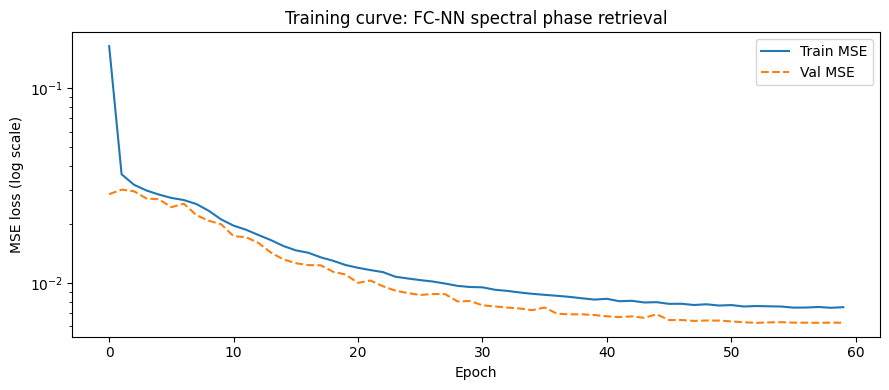

In [9]:
# ─── Training loop ─────────────────────────────────────────────────────────
if TORCH_OK:
    import time

    train_ds = TensorDataset(X_train, Y_train)
    val_ds   = TensorDataset(X_val,   Y_val)
    
    train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
    val_loader   = DataLoader(val_ds,   batch_size=64)
    
    optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=60, eta_min=1e-5)
    criterion = nn.MSELoss()
    
    N_EPOCHS = 60
    train_losses, val_losses = [], []
    best_val = float("inf")
    best_state = None
    
    t0 = time.time()
    for epoch in range(N_EPOCHS):
        model.train()
        batch_losses = []
        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            pred = model(xb)
            loss = criterion(pred, yb)
            optimizer.zero_grad()
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            batch_losses.append(loss.item())
        
        model.eval()
        with torch.no_grad():
            val_loss = sum(criterion(model(xb.to(DEVICE)), yb.to(DEVICE)).item()
                           for xb, yb in val_loader) / len(val_loader)
        
        train_loss = np.mean(batch_losses)
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        scheduler.step()
        
        if val_loss < best_val:
            best_val = val_loss
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        
        if (epoch + 1) % 10 == 0:
            lr = scheduler.get_last_lr()[0]
            elapsed = time.time() - t0
            print(f"Epoch {epoch+1:3d}/{N_EPOCHS} | train={train_loss:.5f} | val={val_loss:.5f} | lr={lr:.2e} | {elapsed:.1f}s")
    
    # Restore best weights
    model.load_state_dict(best_state)
    print(f"\nTraining complete. Best val MSE: {best_val:.5f}")
    
    # Plot training curves
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.semilogy(train_losses, label="Train MSE")
    ax.semilogy(val_losses,   label="Val MSE", linestyle="--")
    ax.set_xlabel("Epoch"); ax.set_ylabel("MSE loss (log scale)")
    ax.set_title("Training curve: FC-NN spectral phase retrieval")
    ax.legend(); plt.tight_layout(); plt.show()

=== Test set results (N=400) ===
Magnitude  RMSE: 0.0994 ± 0.0371
Phase      RMSE: 0.1018 ± 0.0470


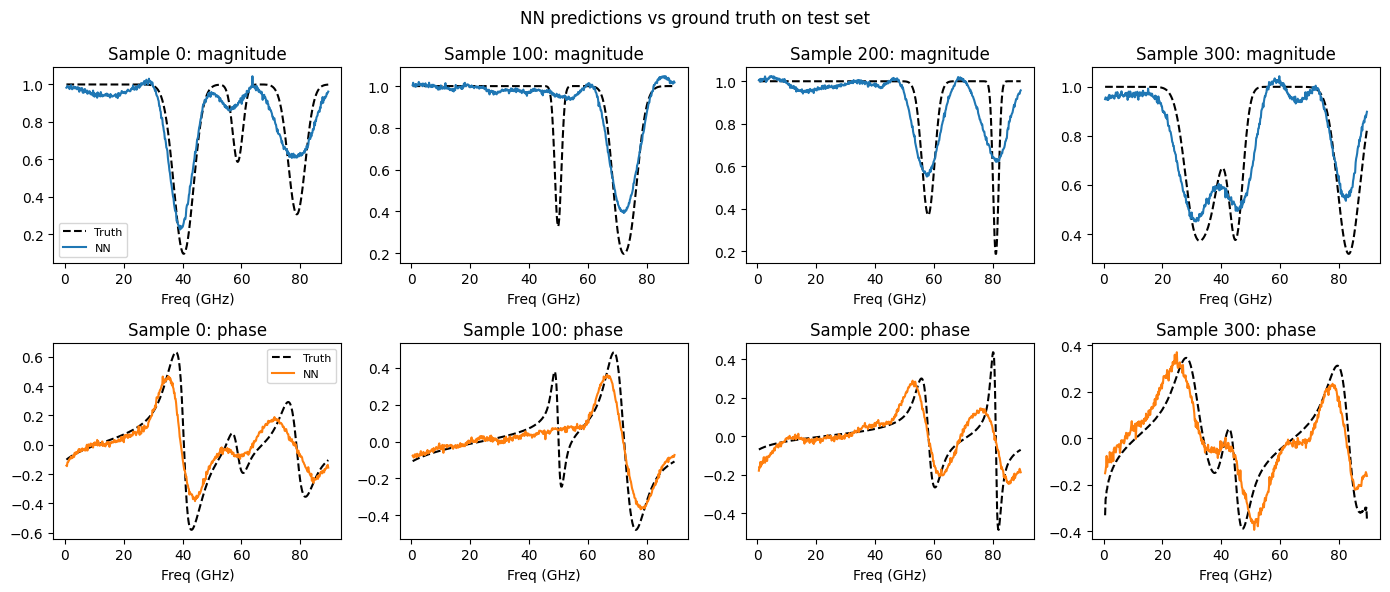

In [10]:
# ─── Evaluation: NN vs GS comparison ───────────────────────────────────────
if TORCH_OK:
    model.eval()
    with torch.no_grad():
        preds = model(X_test.to(DEVICE)).cpu().numpy()
    
    targets = Y_test.numpy()
    
    # Split predictions into magnitude and phase
    pred_mag   = preds[:, :N_net]
    pred_phase = preds[:, N_net:] * np.pi  # undo normalization
    true_mag   = targets[:, :N_net]
    true_phase = targets[:, N_net:] * np.pi
    
    # Per-sample RMSE
    rmse_mag   = np.sqrt(np.mean((pred_mag   - true_mag)**2,   axis=1))
    rmse_phase = np.sqrt(np.mean((pred_phase - true_phase)**2, axis=1))
    
    print("=== Test set results (N={}) ===".format(N_TEST))
    print(f"Magnitude  RMSE: {rmse_mag.mean():.4f} ± {rmse_mag.std():.4f}")
    print(f"Phase      RMSE: {rmse_phase.mean():.4f} ± {rmse_phase.std():.4f}")
    
    # ─── Visual comparison on a few test samples ─────────────────────────────
    n_show = 4
    fig, axes = plt.subplots(2, n_show, figsize=(14, 6))
    
    for i in range(n_show):
        idx = i * (N_TEST // n_show)
        
        axes[0, i].plot(f_net/GHZ, true_mag[idx],   "k--", lw=1.5, label="Truth")
        axes[0, i].plot(f_net/GHZ, pred_mag[idx],   "tab:blue", lw=1.5, label="NN")
        axes[0, i].set_title(f"Sample {idx}: magnitude")
        axes[0, i].set_xlabel("Freq (GHz)")
        if i == 0: axes[0, i].legend(fontsize=8)
        
        axes[1, i].plot(f_net/GHZ, true_phase[idx], "k--", lw=1.5, label="Truth")
        axes[1, i].plot(f_net/GHZ, pred_phase[idx], "tab:orange", lw=1.5, label="NN")
        axes[1, i].set_title(f"Sample {idx}: phase")
        axes[1, i].set_xlabel("Freq (GHz)")
        if i == 0: axes[1, i].legend(fontsize=8)
    
    plt.suptitle("NN predictions vs ground truth on test set")
    plt.tight_layout(); plt.show()

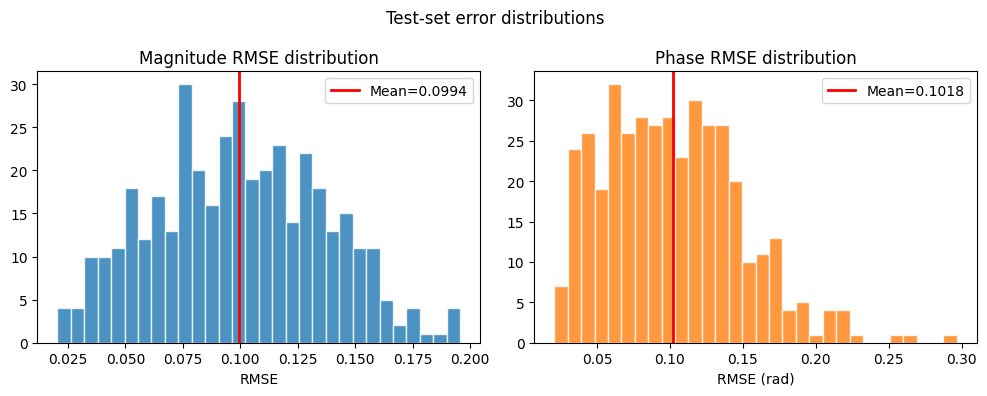

Magnitude correlation:  0.8463
Phase correlation:      0.8085


In [11]:
# ─── RMSE distribution plot ─────────────────────────────────────────────────
if TORCH_OK:
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    
    axes[0].hist(rmse_mag,   bins=30, color="tab:blue",   alpha=0.8, edgecolor="white")
    axes[0].axvline(rmse_mag.mean(), color="red", lw=2, label=f"Mean={rmse_mag.mean():.4f}")
    axes[0].set_xlabel("RMSE"); axes[0].set_title("Magnitude RMSE distribution")
    axes[0].legend()
    
    axes[1].hist(rmse_phase, bins=30, color="tab:orange", alpha=0.8, edgecolor="white")
    axes[1].axvline(rmse_phase.mean(), color="red", lw=2, label=f"Mean={rmse_phase.mean():.4f}")
    axes[1].set_xlabel("RMSE (rad)"); axes[1].set_title("Phase RMSE distribution")
    axes[1].legend()
    
    plt.suptitle("Test-set error distributions")
    plt.tight_layout(); plt.show()
    
    # Correlation coefficients
    cc_mag   = [float(np.corrcoef(pred_mag[i], true_mag[i])[0,1]) for i in range(N_TEST)]
    cc_phase = [float(np.corrcoef(pred_phase[i], true_phase[i])[0,1]) for i in range(N_TEST)]
    print(f"Magnitude correlation:  {np.mean(cc_mag):.4f}")
    print(f"Phase correlation:      {np.mean(cc_phase):.4f}")

---
## Summary and Further Reading

| Method | Inputs required | Phase accuracy | Speed (inference) | Notes |
|--------|----------------|----------------|-------------------|-------|
| **Hilbert transform** | 1 interferogram + shear frequency | Moderate | Very fast | Fails with nonlinear distortions |
| **Gerchberg-Saxton** | 2 intensity planes | Good (physics-constrained) | Slow (iterative) | No training; any new setup runs immediately |
| **FC-NN** | 1 interferogram (trained) | Best in paper | Very fast | Requires retraining for new setups |
| **NN → GS refinement** | NN output as GS seed | Potentially best | Fast | Hybrid — combine both worlds |

### What to explore next

1. **Larger network, more training data** — the paper used 5400 profiles; this notebook used 3000 on a compact grid.
2. **Convolutional layers** — exploit local structure in the interferogram fringes.
3. **Physics-informed loss** — add a term that enforces the KK relation on network outputs.
4. **Transfer learning** — pre-train on synthetic data, fine-tune on a small experimental set.
5. **Noise robustness** — add ADC quantization and AWGN to the training interferograms.

### Reference

Pu, G. & Jalali, B. (2021). *Neural network enabled time stretch spectral regression.*
Optics Express, 29(13), 20785–20799. https://doi.org/10.1364/OE.426178